<a href="https://colab.research.google.com/github/190yenz406/UTS-ANREG-SANAH-24/blob/main/UTSANREG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

versi 1, tanpa perbandingan korelasi yang terkuat

====pemberssihan data=====
Total missing values: 0

Ukuran data setelah cleaning: (230, 15)

Data berhasil dibersihkan.

Statistik Deskriptif:
          BodyFat      Weight
count  230.000000  230.000000
mean    18.523478  176.119783
std      7.873407   24.122487
min      0.000000  118.500000
25%     12.325000  158.062500
50%     18.750000  174.875000
75%     24.575000  193.062500
max     40.100000  241.250000

Koefisien Korelasi Pearson antara Variabel X (BodyFat) dan Variabel Y (Weight): 0.573
Interpretasi: Korelasi sedang positif


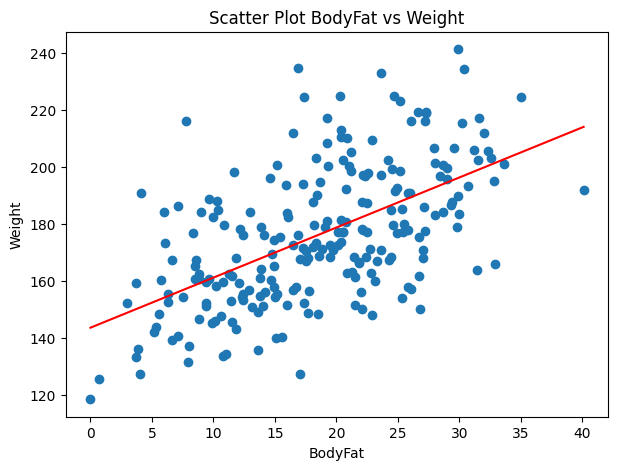


INTERPRETASI KOEFISIEN 
Persamaan Regresi: Weight = 143.58 + 1.76 * BodyFat

Interpretasi:
1. Intercept (β0 = 143.58):
   Nilai Weight ketika BodyFat = 0 adalah 143.58 poin 

2. Slope (β1 = 1.76):
   Setiap penambahan 1 unit BodyFat, nilai Weight berubah sebesar 1.76 poin

PREDIKSI Weight
Jika BodyFat = 45, prediksi Weight = 222.624
Jika BodyFat = 60, prediksi Weight = 248.97
Koefisien Korelasi Pearson: 0.573
P-value: 0.000
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara BodyFat dan Weight dalam populasi.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
import statsmodels.api as sm

df = pd.read_csv('/content/bodyfat.csv')

BodyFat = "BodyFat"
Weight = "Weight"

print('====pemberssihan data=====')
#missing value
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")


#Hapus duplikasi
df = df.drop_duplicates()

#Deteksi Outlier
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nUkuran data setelah cleaning:", df.shape)

# Reset index
df = df.reset_index(drop=True)

print("\nData berhasil dibersihkan.")

#statistika deskriftif
print("\nStatistik Deskriptif:")
print(df[['BodyFat', 'Weight']].describe())

BodyFat_cleaned_array = df[BodyFat].values
Weight_cleaned_array = df[Weight].values

korelasi_pearson, p_value = pearsonr(BodyFat_cleaned_array, Weight_cleaned_array)
print(f"\nKoefisien Korelasi Pearson antara Variabel X ({BodyFat}) dan Variabel Y ({Weight}): {korelasi_pearson:.3f}")

# Interpretasi hasil
if korelasi_pearson > 0.8:
  interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
  interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
  interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
  interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
  interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
  interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
  interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
  interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
  interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
  interpretasi = "Korelasi sangat lemah negatif"
else: interpretasi = "Tidak ada korelasi linier (atau sangat mendekati nol)"

print(f"Interpretasi: {interpretasi}")



#SCATTERPLOT DENGAN GARIS REGRESI
X_ols = sm.add_constant(df[BodyFat])
y_ols = df[Weight]
model = sm.OLS(y_ols, X_ols).fit()

plt.figure(figsize=(7,5))
plt.scatter(df[BodyFat], df[Weight])

slope_linregress, intercept_linregress, _, _, _ = linregress(df[BodyFat], df[Weight])
X_line = np.linspace(df[BodyFat].min(), df[BodyFat].max(), 100)
Y_line = intercept_linregress + slope_linregress * X_line
plt.plot(X_line, Y_line, color='red')

plt.xlabel(BodyFat)
plt.ylabel(Weight)
plt.title(f"Scatter Plot {BodyFat} vs {Weight}")
plt.show()



#INTERPRETASI KOEFISIEN
print("\nINTERPRETASI KOEFISIEN ")
intercept = model.params['const']
slope = model.params[BodyFat]
print(f"Persamaan Regresi: {Weight} = {round(intercept,2)} + {round(slope,2)} * {BodyFat}\n")

print("Interpretasi:")
print(f"1. Intercept (β0 = {round(intercept,2)}):")
print(f"   Nilai {Weight} ketika {BodyFat} = 0 adalah {round(intercept,2)} poin \n")

print(f"2. Slope (β1 = {round(slope,2)}):")
print(f"   Setiap penambahan 1 unit {BodyFat}, nilai {Weight} berubah sebesar {round(slope,2)} poin")



# PREDIKSI
new_data = pd.DataFrame({
    BodyFat: [45, 60]
})

new_data = sm.add_constant(new_data)
prediction = model.get_prediction(new_data)
prediction_summary = prediction.summary_frame(alpha=0.05)

print(f"\nPREDIKSI {Weight}")
print(f"Jika {BodyFat} = 45, prediksi {Weight} = {round(prediction_summary['mean'][0],3)}")
print(f"Jika {BodyFat} = 60, prediksi {Weight} = {round(prediction_summary['mean'][1],3)}")



# Hitung koefisien korelasi Pearson dan p-value
# Tetapkan tingkat signifikansi (alpha)
alpha = 0.05
print(f"Koefisien Korelasi Pearson: {korelasi_pearson:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

#Lakukan uji hipotesis
if p_value < alpha:
  keputusan = "Tolak Hipotesis Nol (H0)"
  interpretasi_uji = f"Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara {BodyFat} dan {Weight} dalam populasi."
else:
  keputusan = "Gagal Menolak Hipotesis Nol (H0)"
  interpretasi_uji = f"Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara {BodyFat} dan {Weight} dalam populasi."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

versi 2 membandingkan variabel  mana yang korelasi terkuat dengan bodyfat

====pemberssihan data=====
Total missing values: 0

Ukuran data setelah cleaning: (230, 15)

Data berhasil dibersihkan.

Weight dengan exam_score
r = 0.6124
p-value = 0.00000000
Interpretasi = Korelasi kuat positif

Thigh dengan exam_score
r = 0.5596
p-value = 0.00000000
Interpretasi = Korelasi sedang positif

Abdomen dengan exam_score
r = 0.8134
p-value = 0.00000000
Interpretasi = Korelasi sangat kuat positif


KORELASI TERKUAT:Abdomen dengan BodyFat

Statistik Deskriptif:
          Abdomen     BodyFat
count  230.000000  230.000000
mean    91.526087   18.523478
std      9.161325    7.873407
min     69.400000    0.000000
25%     84.425000   12.325000
50%     90.750000   18.750000
75%     98.525000   24.575000
max    118.000000   40.100000

r = 0.8134
p-value = 0.000000
Interpretasi = Korelasi sangat kuat positif


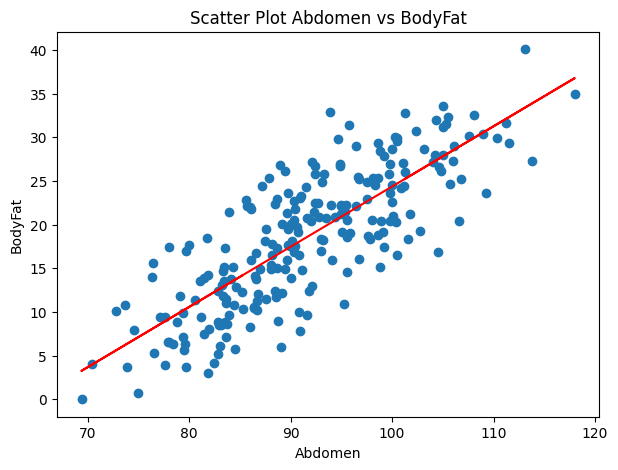


INTERPRETASI KOEFISIEN 
Persamaan Regresi: BodyFat = -44.63 + 0.69 * Abdomen

Interpretasi:
1. Intercept (β0 = -44.63):
   Nilai BodyFat ketika Abdomen = 0 adalah -44.63 poin 

2. Slope (β1 = 0.69):
   Setiap penambahan pengalaman 1cm, nilai BodyFat meningkat sebesar 0.69 poin

PREDIKSI BODYFAT
Jika Abdomen = 45 cm, prediksi BodyFat = -13.581
Jika Abdomen = 60 cm, prediksi BodyFat = -3.231

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Variabel X dan Variabel Y dalam populasi.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
import statsmodels.api as sm

df = pd.read_csv('/content/bodyfat.csv')

Weight = np.array(df["Weight"])
Thigh = np.array(df["Thigh"])
Abdomen = np.array(df["Abdomen"])
BodyFat = np.array(df["BodyFat"])

print('====pemberssihan data=====')
#missing value
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")


#Hapus duplikasi
df = df.drop_duplicates()

#Deteksi Outlier
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nUkuran data setelah cleaning:", df.shape)

# Reset index
df = df.reset_index(drop=True)

print("\nData berhasil dibersihkan.")

#perbandingan
pairs = [
    ("Weight", Weight, BodyFat),
    ("Thigh", Thigh, BodyFat),
    ("Abdomen", Abdomen , BodyFat)
]

results = {}

#Hitung Korelasi Pearson dan Interpretasi hasil

for name, x, y in pairs:
    r, p = pearsonr(x, y)
    results[name] = (r, p)

    if r > 0.8:
        interpretasi = "Korelasi sangat kuat positif"
    elif r > 0.6:
        interpretasi = "Korelasi kuat positif"
    elif r > 0.4:
        interpretasi = "Korelasi sedang positif"
    elif r > 0.2:
        interpretasi = "Korelasi lemah positif"
    elif r > 0:
        interpretasi = "Korelasi sangat lemah positif"
    elif r < -0.8:
        interpretasi = "Korelasi sangat kuat negatif"
    elif r < -0.6:
        interpretasi = "Korelasi kuat negatif"
    elif r < -0.4:
        interpretasi = "Korelasi sedang negatif"
    elif r < -0.2:
        interpretasi = "Korelasi lemah negatif"
    elif r < 0:
        interpretasi = "Korelasi sangat lemah negatif"
    else:
        interpretasi = "Tidak ada korelasi linier"

    print(f"\n{name} dengan exam_score")
    print(f"r = {r:.4f}")
    print(f"p-value = {p:.8f}")
    print(f"Interpretasi = {interpretasi}")


#Uji Hipotesis Korelasi Terkuat

strongest = max(results.items(), key=lambda item: abs(item[1][0]))
variabel_terkuat, (r_strong, p_strong) = strongest

n = len(df)
t_stat = r_strong * np.sqrt((n - 2) / (1 - r_strong**2))

print('\n================================================')

#HASIL
print(f"\nKORELASI TERKUAT:{variabel_terkuat} dengan BodyFat")
print("\nStatistik Deskriptif:")
print(df[[variabel_terkuat, 'BodyFat']].describe())
print(f"\nr = {r_strong:.4f}")
print(f"p-value = {p_strong:.6f}")
print(f"Interpretasi = {interpretasi}")



#SCATTERPLOT DENGAN GARIS REGRESI
x = sm.add_constant(df[variabel_terkuat])
model = sm.OLS(df['BodyFat'], x).fit()
plt.figure(figsize=(7,5))
plt.scatter(df[variabel_terkuat],df['BodyFat'])

slope, intercept, _, _, _ = linregress(df[variabel_terkuat], df['BodyFat'])
X_line = np.linspace(df[variabel_terkuat].min(), df[variabel_terkuat].max(), 100)
Y_line = intercept + slope * X_line

plt.plot(df[variabel_terkuat], model.predict(x), color='red')
plt.xlabel(variabel_terkuat)
plt.ylabel("BodyFat")
plt.title(f"Scatter Plot {variabel_terkuat} vs BodyFat")
plt.show()


#INTERPRETASI KOEFISIEN
print("\nINTERPRETASI KOEFISIEN ")
intercept = model.params['const']
slope = model.params[variabel_terkuat]

print(f"Persamaan Regresi: BodyFat = {round(intercept,2)} + {round(slope,2)} * {variabel_terkuat}\n")

print("Interpretasi:")
print(f"1. Intercept (β0 = {round(intercept,2)}):")
print(f"   Nilai BodyFat ketika {variabel_terkuat} = 0 adalah {round(intercept,2)} poin \n")

print(f"2. Slope (β1 = {round(slope,2)}):")
print(f"   Setiap penambahan pengalaman 1cm, nilai BodyFat meningkat sebesar {round(slope,2)} poin")



# PREDIKSI BODYFAT DENGAN ABDOMEN
new_data = pd.DataFrame({
    'Abdomen': [45, 60]
})

new_data = sm.add_constant(new_data)
prediction = model.get_prediction(new_data)
prediction_summary = prediction.summary_frame(alpha=0.05)

print("\nPREDIKSI BODYFAT")
print(f"Jika Abdomen = 45 cm, prediksi BodyFat = {round(prediction_summary['mean'][0],3)}")
print(f"Jika Abdomen = 60 cm, prediksi BodyFat = {round(prediction_summary['mean'][1],3)}")



# UJI HIPOTESIS
alpha = 0.05
if p_strong < alpha:
  keputusan = "Tolak Hipotesis Nol (H0)"
  interpretasi_uji = "Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Variabel X dan Variabel Y dalam populasi."
else:
  keputusan = "Gagal Menolak Hipotesis Nol (H0)"
  interpretasi_uji = "Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Variabel X dan Variabel Y dalam populasi."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")